<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [14]:
## Write your code here
print("Colum names: ","\n\n",df.columns)
print("")
df.info()
print("")
print("Size of datase: ",df.shape)


Colum names:  

 Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB

Size of datase:  (65437, 114)


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [21]:
## Write your code here
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(20)


df['Age'] = df['Age'].fillna(df['Age'].mode()[0])
df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['EdLevel'] = df['EdLevel'].fillna(df['EdLevel'].mode()[0])

In [23]:

imputed_columns = ['Age','Employment','JobSat','RemoteWork','EdLevel']
df[imputed_columns].isnull().sum()

Age           0
Employment    0
JobSat        0
RemoteWork    0
EdLevel       0
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [34]:
print("Employment value counts")
print(df['Employment'].value_counts().head(10))
print("")
print("JobSat value counts")
print(df['JobSat'].value_counts().head(10))
print("")
print("YearsCodePro value counts")
print(df['YearsCodePro'].value_counts().head(10))

Employment value counts
Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Employed, full-time;Student, full-time                                        897
Employed, full-time;Student, part-time                                        839
Student, full-time;Not employed, but looking for work                         686
Name: count, dtype: int64

JobSat value counts
JobSat
7.0     42690
8.0      7509
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0    

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


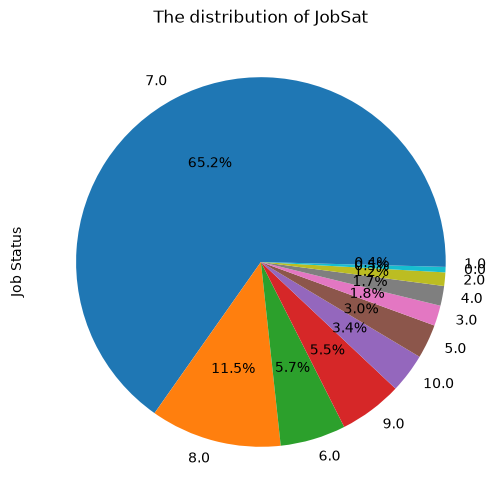

In [39]:
## Write your code here
plt.figure(figsize = (6,6))
df["JobSat"].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title("The distribution of JobSat")
plt.ylabel("Job Status")
plt.show()

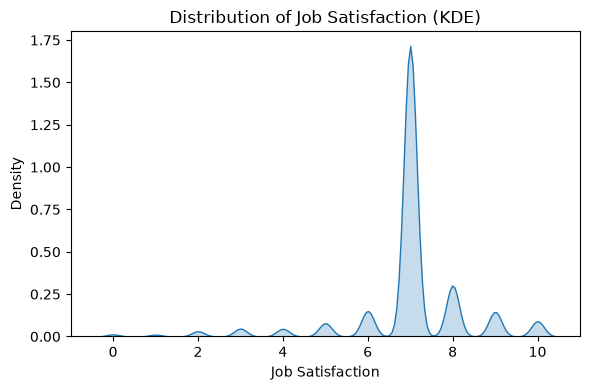

In [41]:
## Write your code here
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x='JobSat', fill=True)
plt.title('Distribution of Job Satisfaction (KDE)')
plt.xlabel('Job Satisfaction')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


<Figure size 1200x600 with 0 Axes>

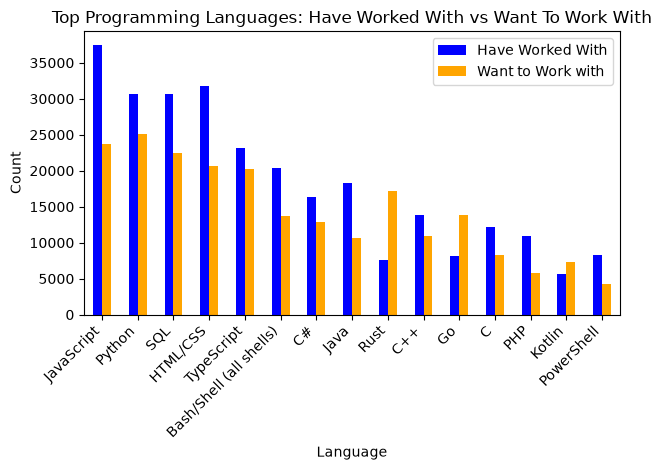

In [49]:
## Write your code here
def extract_lang(series):
    languages = series.dropna().str.split(';').explode().str.strip()
    return languages.value_counts().head(15)

lang_worked_counts = extract_lang(df['LanguageHaveWorkedWith'])
lang_want_counts = extract_lang(df['LanguageWantToWorkWith'])

lang_comparison = pd.DataFrame({'Have Worked With': lang_worked_counts,
                                'Want to Work with':lang_want_counts
                               }).fillna(0).astype(int)

top_langs = lang_comparison.sum(axis =1).sort_values(ascending = False).head(15).index

plt.figure(figsize= (12,6))
lang_comparison.loc[top_langs].plot(kind= 'bar', color = ['blue','orange'])
plt.title('Top Programming Languages: Have Worked With vs Want To Work With')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


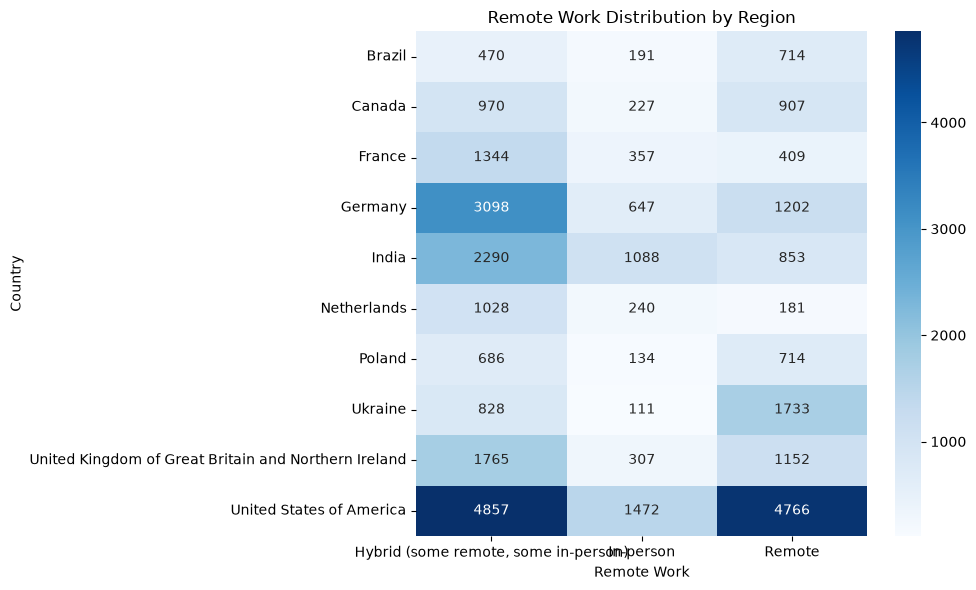

In [50]:
## Write your code here
top_countries = df["Country"].value_counts().head(10).index
df_region = df[df["Country"].isin(top_countries)]

remoteW_by_reg = pd.crosstab(df_region["Country"],df_region["RemoteWork"])

plt.figure(figsize=(10, 6))
sns.heatmap(remoteW_by_reg , annot=True, fmt='d', cmap='Blues')
plt.title('Remote Work Distribution by Region')
plt.xlabel('Remote Work')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

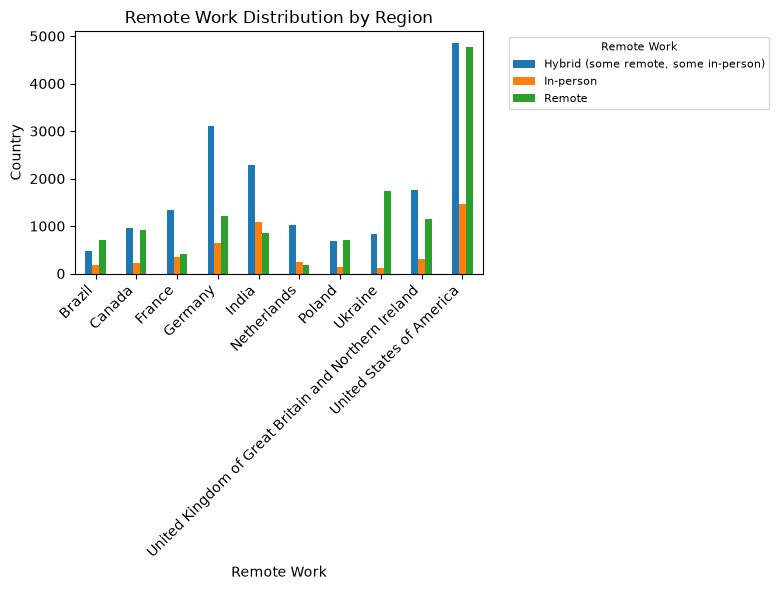

In [69]:
remoteW_by_reg.plot(kind = 'bar',figsize=(8, 6))
plt.title('Remote Work Distribution by Region')
plt.xlabel('Remote Work')
plt.ylabel('Country')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Remote Work', fontsize = 8, title_fontsize=8, bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [83]:
!pip install scipy
from scipy import stats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 203.7 MB/s eta 0:00:00


In [86]:
## Write your code here


import numpy as np
def years_to_numeric(value):
    if pd.isna(value):
        return np.nan
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 51
    return float(value)

df['YearsCodePro_Num'] = df['YearsCodePro'].apply(years_to_numeric)
df_correlation = df[['YearsCodePro_Num','JobSat']].dropna()

pearson_corr = df_correlation['YearsCodePro_Num'].corr(df_correlation['JobSat'], method='pearson')
spearman_corr = df_correlation['YearsCodePro_Num'].corr(df_correlation['JobSat'], method='spearman')

print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
df_correlation[['YearsCodePro_Num', 'JobSat']].corr()

Pearson correlation: 0.0720
Spearman correlation: 0.0900


,YearsCodePro_Num,JobSat
YearsCodePro_Num,1.000000,0.071994
JobSat,0.071994,1.000000


In [77]:
df[['YearsCodePro_Num','JobSat']].value_counts().head()

YearsCodePro_Num  JobSat
2.0               7.0       2556
3.0               7.0       2337
0.5               7.0       2249
5.0               7.0       1986
4.0               7.0       1778
Name: count, dtype: int64

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


/tmp/ipykernel_1621/1544972872.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1000 with 0 Axes>

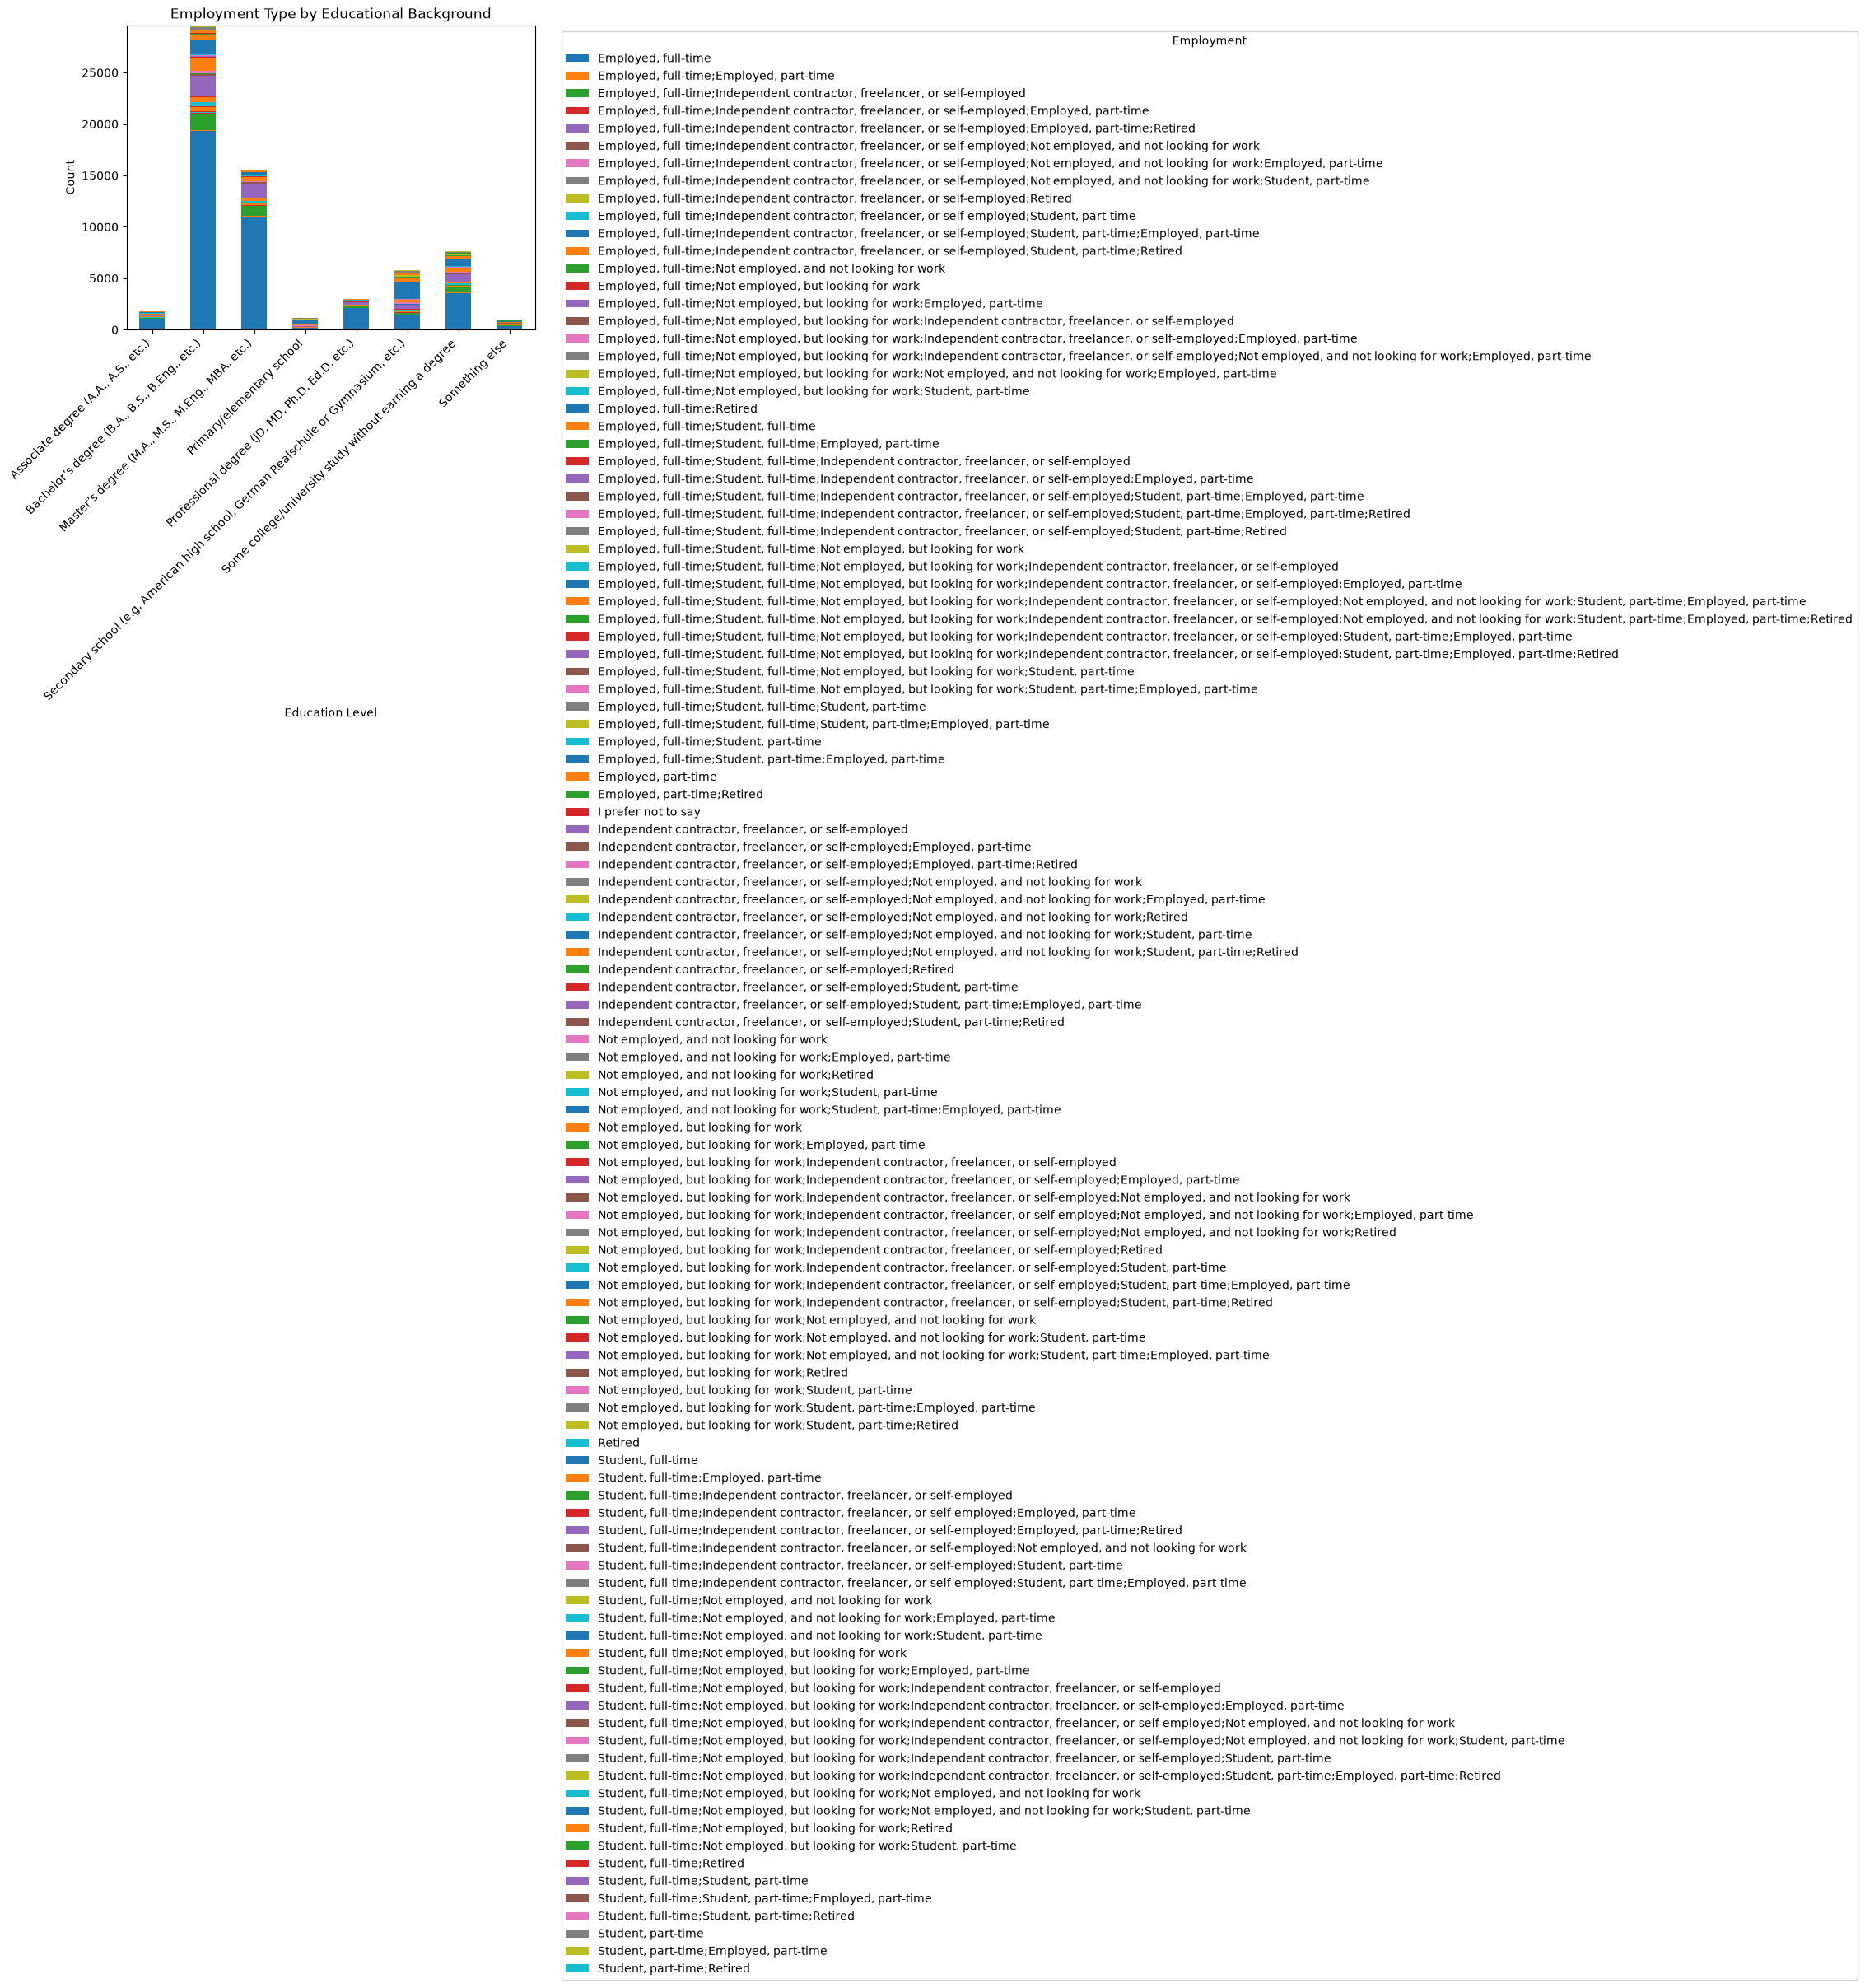

In [97]:
## Write your code here
emp_ed_relationn = pd.crosstab(df["EdLevel"],df["Employment"])
emp_ed_relationn

plt.figure(figsize=(12,10))
emp_ed_relationn.plot(kind='bar',stacked=True,)

plt.title('Employment Type by Educational Background')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Employment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [99]:
## Write your code here
cleaned_data = 'cleaned-survey-data-distribution.csv'
df.head(500).to_csv(cleaned_data, index = False)
print("Cleaned data has been saved to directory: ",cleaned_data)

Cleaned data has been saved to directory:  cleaned-survey-data-distribution.csv


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
